# THREE different methods are done in this notebook

### 1) Loaded train.csv


### 2)Loaded test.csv

### 3)Loaded train & test data to save new data

In [84]:
import pandas as pd
import seaborn as sns
import numpy as np
import warnings as w
w.filterwarnings('ignore')

# 1) Loaded train.csv

In [2]:
train=pd.read_csv("train.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
from sklearn.impute import SimpleImputer

In [5]:
s=SimpleImputer(strategy="most_frequent")
train[['Age']]=s.fit_transform(train[['Age']])

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>

RangeIndex: 891 entries, 0 to 890

Data columns (total 12 columns):

 #   Column       Non-Null Count  Dtype  

---  ------       --------------  -----  

 0   PassengerId  891 non-null    int64  

 1   Survived     891 non-null    int64  

 2   Pclass       891 non-null    int64  

 3   Name         891 non-null    object 

 4   Sex          891 non-null    object 

 5   Age          891 non-null    float64

 6   SibSp        891 non-null    int64  

 7   Parch        891 non-null    int64  

 8   Ticket       891 non-null    object 

 9   Fare         891 non-null    float64

 10  Cabin        204 non-null    object 

 11  Embarked     889 non-null    object 

dtypes: float64(2), int64(5), object(5)

memory usage: 83.7+ KB


In [7]:
col=train[['Sex']]

In [8]:
from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()
for i in col:
    col[i]=l.fit_transform(col[i])
train[['Sex']]=col

In [9]:
train.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891.000000,891.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,NaN,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",NaN,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,0.647587,28.566970,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,0.477990,13.199572,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,0.000000,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,0.000000,22.000000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,1.000000,24.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,1.000000,35.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


<AxesSubplot:xlabel='Survived', ylabel='Age'>

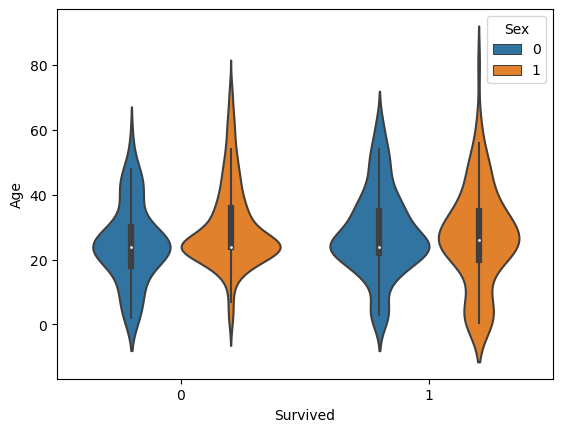

In [10]:
sns.violinplot(data=train,x='Survived',y='Age',hue="Sex",kind="bar")

In [11]:
train.drop(['PassengerId','Name','Ticket','Fare','Embarked','Cabin'],axis=1,inplace=True)

In [12]:
train.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch'], dtype='object')

In [13]:
x=train.drop(['Survived'],axis=1)

In [14]:
y=train[['Survived']]

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

In [16]:
x

,Pclass,Sex,Age,SibSp,Parch
0,3,1,22.0,1,0
1,1,0,38.0,1,0
2,3,0,26.0,0,0
3,1,0,35.0,1,0
4,3,1,35.0,0,0
...,...,...,...,...,...
886,2,1,27.0,0,0
887,1,0,19.0,0,0
888,3,0,24.0,1,2
889,1,1,26.0,0,0


# AutoML

In [17]:
from pycaret.classification import setup,compare_models,create_model,tune_model,evaluate_model

In [18]:
model=setup(train,target='Survived')

,Description,Value
0,Session id,5379
1,Target,Survived
2,Target type,Binary
3,Original data shape,"(891, 6)"
4,Transformed data shape,"(891, 6)"
5,Transformed train set shape,"(623, 6)"
6,Transformed test set shape,"(268, 6)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,simple


In [19]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8235,0.8598,0.7158,0.8113,0.7556,0.6188,0.6261,0.3390
lightgbm,Light Gradient Boosting Machine,0.8219,0.8627,0.7241,0.7959,0.7536,0.6153,0.6214,0.5450
qda,Quadratic Discriminant Analysis,0.8124,0.8542,0.7406,0.7672,0.7495,0.6001,0.6047,0.3200
ada,Ada Boost Classifier,0.8121,0.8568,0.7408,0.7677,0.7482,0.5993,0.6056,0.3410
rf,Random Forest Classifier,0.8106,0.8498,0.7447,0.7588,0.7485,0.5969,0.6008,0.3960
xgboost,Extreme Gradient Boosting,0.7994,0.8428,0.7156,0.7490,0.7296,0.5707,0.5734,0.3330
et,Extra Trees Classifier,0.7993,0.8377,0.7072,0.7578,0.7283,0.5699,0.5737,0.4010
lr,Logistic Regression,0.7834,0.8521,0.6947,0.7361,0.7097,0.5379,0.5432,0.8100
ridge,Ridge Classifier,0.7769,0.0000,0.6699,0.7269,0.6934,0.5195,0.5237,0.3190
lda,Linear Discriminant Analysis,0.7769,0.8499,0.6699,0.7269,0.6934,0.5195,0.5237,0.2940


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='deviance', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=5379, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

In [20]:
best=create_model("lightgbm")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8571,0.8429,0.6667,0.9412,0.7805,0.6791,0.7013
1,0.9048,0.9274,0.9167,0.8462,0.8800,0.8013,0.8030
2,0.6825,0.7308,0.5000,0.6000,0.5455,0.3046,0.3076
3,0.8387,0.8838,0.6667,0.8889,0.7619,0.6437,0.6589
4,0.7581,0.7982,0.5833,0.7368,0.6512,0.4698,0.4773
5,0.8387,0.8986,0.7500,0.8182,0.7826,0.6548,0.6564
6,0.8226,0.8531,0.7083,0.8095,0.7556,0.6173,0.6207
7,0.8065,0.8887,0.7500,0.7500,0.7500,0.5921,0.5921
8,0.8710,0.9550,0.9167,0.7857,0.8462,0.7362,0.7427


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [21]:
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

# MODEL 

In [22]:
from lightgbm import LGBMClassifier

In [23]:
LGBM=LGBMClassifier()
m=LGBM.fit(X_train,y_train)

In [24]:
print(train.Parch.max())
print(train.Pclass.max())
print(train.SibSp.max())

6

3

8


In [25]:
hi=pd.DataFrame({'Pclass':[3],
                "Sex":[1],
                "Age":[24],
                "SibSp":[8],
                "Parch":[6]})
hi.head()

,Pclass,Sex,Age,SibSp,Parch
0,3,1,24,8,6


In [26]:
m.predict(hi)

array([0], dtype=int64)

# 2) Loaded test.csv

In [27]:
test=pd.read_csv('test.csv')
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [28]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [29]:
from sklearn.impute import SimpleImputer

In [30]:
simple=SimpleImputer(strategy="most_frequent")
test[['Age']]=simple.fit_transform(test[['Age']])

In [31]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

<AxesSubplot:xlabel='Sex', ylabel='Age'>

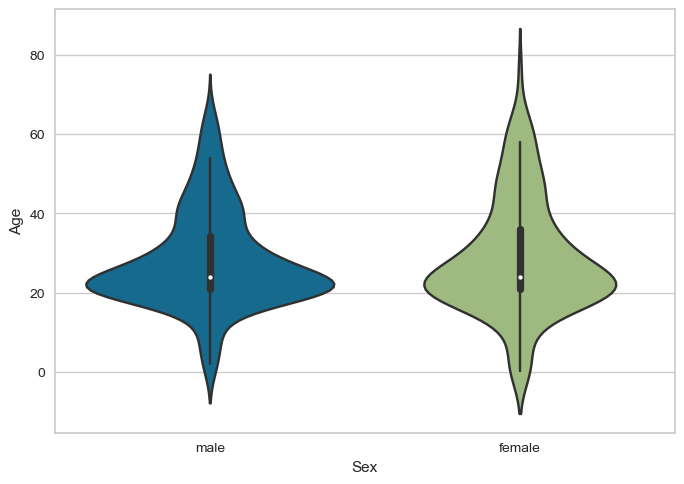

In [32]:
sns.violinplot(data=test,y="Age",x="Sex")

In [33]:
test[['Sex']]=test[['Sex']].replace("male",value=1)

In [34]:
test[['Sex']]=test[['Sex']].replace("female",value=0)

In [35]:
test.Sex.head()

0    1
1    0
2    1
3    1
4    0
Name: Sex, dtype: int64

In [36]:
test.drop(['PassengerId','Name','Ticket','Fare','Embarked','Cabin'],inplace=True,axis=1)

In [37]:
test.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch'], dtype='object')

In [38]:
x_testing=test.drop(['Pclass'],axis=1)
y_testing=test.Pclass

# AutoML

In [39]:
setup(test,target="Pclass")

,Description,Value
0,Session id,2217
1,Target,Pclass
2,Target type,Multiclass
3,Target mapping,"1: 0, 2: 1, 3: 2"
4,Original data shape,"(418, 5)"
5,Transformed data shape,"(418, 5)"
6,Transformed train set shape,"(292, 5)"
7,Transformed test set shape,"(126, 5)"
8,Numeric features,4
9,Preprocess,True


In [40]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.6470,0.7270,0.6470,0.5156,0.5595,0.3485,0.4126,0.3050
ridge,Ridge Classifier,0.6402,0.0000,0.6402,0.5095,0.5535,0.3374,0.3994,0.3540
lr,Logistic Regression,0.6368,0.7301,0.6368,0.5084,0.5519,0.3348,0.3943,0.3810
qda,Quadratic Discriminant Analysis,0.6229,0.6999,0.6229,0.6322,0.6072,0.3579,0.3717,0.3010
nb,Naive Bayes,0.6057,0.7040,0.6057,0.5921,0.5820,0.3232,0.3369,0.3390
lightgbm,Light Gradient Boosting Machine,0.6026,0.6953,0.6026,0.5559,0.5630,0.3109,0.3287,0.3750
ada,Ada Boost Classifier,0.5893,0.7035,0.5893,0.5565,0.5469,0.2786,0.2985,0.3530
gbc,Gradient Boosting Classifier,0.5891,0.7008,0.5891,0.5633,0.5628,0.3001,0.3102,0.5890
xgboost,Extreme Gradient Boosting,0.5789,0.6639,0.5789,0.5478,0.5502,0.2802,0.2920,0.4570
rf,Random Forest Classifier,0.5715,0.6464,0.5715,0.5553,0.5528,0.2726,0.2805,0.4270


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001)

# MODEL

In [41]:
from sklearn.linear_model import RidgeClassifier

In [42]:
ridge=RidgeClassifier()
pred=ridge.fit(x_testing,y_testing)

In [43]:
x_testing.head()

,Sex,Age,SibSp,Parch
0,1,34.5,0,0
1,0,47.0,1,0
2,1,62.0,0,0
3,1,27.0,0,0
4,0,22.0,1,1


In [107]:
print(test.Parch.max())
print(test.SibSp.max())

9

8


In [108]:
hello=pd.DataFrame({"Sex":[0],"Age":[24],"SibSp":[5],"Parch":[9]})
hello.head()

,Sex,Age,SibSp,Parch
0,0,24,5,9


In [109]:
pred.predict(hello)

array([3], dtype=int64)

In [47]:
new=create_model("ridge")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7000,0.0000,0.7000,0.5500,0.6062,0.4304,0.5144
1,0.6333,0.0000,0.6333,0.4852,0.5494,0.3413,0.3764
2,0.6207,0.0000,0.6207,0.4858,0.5404,0.3645,0.3981
3,0.5862,0.0000,0.5862,0.4474,0.5071,0.2840,0.3110
4,0.6552,0.0000,0.6552,0.5517,0.5635,0.3379,0.4598
5,0.6552,0.0000,0.6552,0.5440,0.5676,0.3424,0.4291
6,0.6552,0.0000,0.6552,0.5440,0.5676,0.3424,0.4291
7,0.6207,0.0000,0.6207,0.4988,0.5388,0.2879,0.3418
8,0.7241,0.0000,0.7241,0.5764,0.6379,0.4978,0.5524


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [48]:
evaluate_model(new)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

# 3) Loaded train & test data to save new data

In [110]:
data_train=pd.read_csv("train.csv")
data_test=pd.read_csv("test.csv")

### Preprocessing

In [111]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>

RangeIndex: 418 entries, 0 to 417

Data columns (total 11 columns):

 #   Column       Non-Null Count  Dtype  

---  ------       --------------  -----  

 0   PassengerId  418 non-null    int64  

 1   Pclass       418 non-null    int64  

 2   Name         418 non-null    object 

 3   Sex          418 non-null    object 

 4   Age          332 non-null    float64

 5   SibSp        418 non-null    int64  

 6   Parch        418 non-null    int64  

 7   Ticket       418 non-null    object 

 8   Fare         417 non-null    float64

 9   Cabin        91 non-null     object 

 10  Embarked     418 non-null    object 

dtypes: float64(2), int64(4), object(5)

memory usage: 36.0+ KB


In [112]:
data_test['Sex']=data_test['Sex'].replace("male",value=1)
data_test['Sex']=data_test['Sex'].replace("female",value=0)
data_train['Sex']=data_train['Sex'].replace("male",value=1)
data_train['Sex']=data_train['Sex'].replace("female",value=0)

In [113]:
sile=SimpleImputer(strategy="most_frequent")
data_test[['Age']]=sile.fit_transform(data_test[['Age']])
siles=SimpleImputer(strategy="most_frequent")
data_train[['Age']]=siles.fit_transform(data_train[['Age']])

### Splitted

In [114]:
y1=data_train.Survived
x1=data_train[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch']]

### Model created

In [115]:
from lightgbm import LGBMClassifier
lgc=LGBMClassifier()
lgc.fit(x1,y1)

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=None, reg_alpha=0.0, reg_lambda=0.0, silent='warn',
               subsample=1.0, subsample_for_bin=200000, subsample_freq=0)

### Predictions

In [116]:
 X_tests=data_test[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch']]
predictions = lgc.predict(X_tests)

### Save data

In [117]:
done=pd.DataFrame({"PassengerId":data_test.PassengerId,
                  "Survived":predictions})
done.value_counts()

PassengerId  Survived
892          0           1
1205         0           1
1177         0           1
1176         1           1
1175         0           1
                        ..
1028         0           1
1027         0           1
1026         0           1
1025         0           1
1309         1           1
Length: 418, dtype: int64

In [118]:
done.to_csv("submission.csv",index=False)

# THANK YOU

  ----------------------------------------------------------------------------------------------------- Code By Sapparapu Pradeep